#### 이탈고객 예측

#### 데이터 전처리(결측치 처리, 클래스 불균형 확인 및 처리)
#### 특성 공학 - 피처 선정 또는 피처 생성
#### 베이스 모델 선정
    - 분류 모델 : LogisticRegression
    - 클래스 리포트, 과적합 여부
### 베이스 모델의 성능을 상회하는 모델과 하이퍼 파라미터 조합을 찾아서 성능을 출력

In [230]:
# 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import f1_score

In [231]:
# 텔레콤 소비자 정보 데이터 조회
url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/tellecom.csv'
df = pd.read_csv(url)

In [232]:
df.describe().columns.to_list()

['SeniorCitizen', 'tenure', 'MonthlyCharges']

#### 해당 데이터 열정보별 데이터 의미정리
| 열 이름                 | 의미                             | 데이터 유형   | 예시                                                                                         |
| -------------------- | ------------------------------ | -------- | ------------------------------------------------------------------------------------------ |
| **customerID**       | 각 고객을 구분하는 고유 ID               | 문자열      | `7590-VHVEG`                                                                               |
| **gender**           | 고객의 성별                         | 범주형      | `Male`, `Female`                                                                           |
| **SeniorCitizen**    | 고령자 여부 (보통 1이면 65세 이상, 0이면 미만) | 이진형(0/1) | `0`                                                                                        |
| **Partner**          | 배우자(파트너) 유무                    | 범주형      | `Yes`, `No`                                                                                |
| **Dependents**       | 부양가족(자녀, 부모 등) 유무              | 범주형      | `Yes`, `No`                                                                                |
| **tenure**           | 서비스 이용 개월 수                    | 수치형      | `12`, `72`                                                                                 |
| **PhoneService**     | 전화 서비스 가입 여부                   | 범주형      | `Yes`, `No`                                                                                |
| **MultipleLines**    | 복수 전화 회선 사용 여부                 | 범주형      | `Yes`, `No`, `No phone service`                                                            |
| **InternetService**  | 인터넷 서비스 유형                     | 범주형      | `DSL`, `Fiber optic`, `No`                                                                 |
| **OnlineSecurity**   | 온라인 보안 서비스 이용 여부               | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **OnlineBackup**     | 온라인 백업 서비스 이용 여부               | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **DeviceProtection** | 기기 보호(보험 등) 서비스 이용 여부          | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **TechSupport**      | 기술 지원 서비스 이용 여부                | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **StreamingTV**      | 스트리밍 TV 서비스 이용 여부              | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **StreamingMovies**  | 스트리밍 영화 서비스 이용 여부              | 범주형      | `Yes`, `No`, `No internet service`                                                         |
| **Contract**         | 계약 형태                          | 범주형      | `Month-to-month`, `One year`, `Two year`                                                   |
| **PaperlessBilling** | 종이 없는(전자) 청구서 사용 여부            | 범주형      | `Yes`, `No`                                                                                |
| **PaymentMethod**    | 결제 방식                          | 범주형      | `Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)` |
| **MonthlyCharges**   | 월 요금                           | 연속형 수치   | `70.35`                                                                                    |
| **TotalCharges**     | 총 요금(가입 이후 누적 금액)              | 연속형 수치   | `1397.47`                                                                                  |
| **Churn**            | 고객 이탈 여부 (서비스 해지 여부)           | 범주형      | `Yes`, `No`                                                                                |


In [233]:
# 데이터 전처리 목록
# 결측치 확인 - 해당 데이터 결측치 비율 확인하기
# 데이터 타입 확인
# 중복 데이터 여부 확인

# True : 1, False : 0으로 변환 :
    # Partner, Dependents
    # PhoneService, MultipleLines, InternetService,OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
    # PaperlessBilling
    # Churn

# 고객 ID열 삭제
# 0개월인 고객만 tenure = 1로 바꾸기
# 이상치 처리

# 파생 변수 생성 (Feature Engineering)
# 변수명			의미						생성 방법/설명
# is_family			배우자 또는 부양가족 존재 여부	있다면 1, 없다면 0으로 표시
# num_services		고객이 가입한 서비스 개수		8개의 서비스 가입 갯수 합계
# AvgMonthlyCharge	월 평균 지불 요금			TotalCharges / (tenure+1) -> 0개월인 고객만 tenure = 1로 바꿔 계산
# ChargePerService	서비스당 평균 요금				MonthlyCharges / num_services

# 다중 범주형 데이터는 One-Hot Encoding하기 ?

# 수치형 데이터는 스케일링 하기 : StandardScaler 또는 MinMaxScaler 적용 택1 : 전체 데이터 분포 확인하기 시각화

# 고객이탈 여부를 기준으로 데이터 불균형 여부 확인하기

In [234]:
# 데이터 조회
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [235]:
df.columns.to_list()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [236]:
df.info()
# 수치형이여야 되는 데 dtype이 object인 열 :
    # TotalCharges
# 여부를 Yes : 1, No : 0 로 매핑 :
    # Partner, Dependents
    # PhoneService, MultipleLines, InternetService,OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
    # PaperlessBilling
    # Churn

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [237]:
# dtype을 object에서 수치형으로 변경되도록 숫자가 아닌 수를 nan 처리
df.TotalCharges = pd.to_numeric(df.TotalCharges,errors='coerce')

# nan 차지 비율 확인
print(len(df.TotalCharges), df['TotalCharges'].isna().sum())

# nan 처리 : 제거
df.dropna(inplace=True)

7043 11


In [238]:
# 중복 데이터 조회
print(df.duplicated().sum())

# 중복 데이터 삭제(기본값 : 한개는 남김)
df.drop_duplicates(keep='first')

0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [239]:
df.describe().columns.to_list()

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [240]:
# True : 1, False : 0으로 변환 :
# 변환할 열 목록
cols_to_map = [
    'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

# Yes → 1, No → 0 매핑
yes_no_map = {'Yes': 1, 'No': 0}

for col in cols_to_map:
    # InternetService처럼 'No internet service' 같은 경우도 있는 열은 먼저 'No'로 처리
    if df[col].dtype == object:
        df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
        df[col] = df[col].map(yes_no_map)
# df.head()

In [241]:
# 고객 ID열 삭제
df = df.drop('customerID', axis=1)

In [242]:
# 0개월인 고객만 tenure = 1로 바꾸기
df['tenure'] = df['tenure'].replace({'0': '1'})

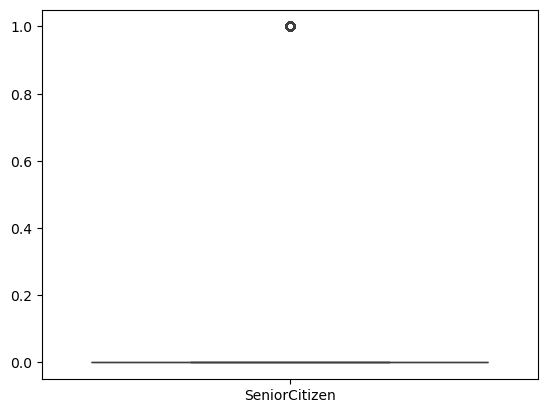

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [243]:
# 이상치 처리
# 박스플롯으로 이상치가 있는지 확인
# 기존 수치형 데이터들 검토 : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'] 하나씩 지워가며 이상치 여부 확인하였다. ^ 자동화 가능?
sns.boxplot(data=df[['SeniorCitizen']], showfliers=True)  # showfliers=True가 이상치 점 표시
plt.show()
df['SeniorCitizen'].value_counts() # 이상치 없음 확인, 0과 1로 나타내는 데이터

In [244]:
# 파생 변수 생성 (Feature Engineering)
# 변수명			의미						생성 방법/설명
# is_family			배우자 또는 부양가족 존재 여부	있다면 1, 없다면 0으로 표시
# num_services		고객이 가입한 서비스 개수		8개의 서비스 가입 갯수 합계
# AvgMonthlyCharge	월 평균 지불 요금			TotalCharges / (tenure+1) -> 0개월인 고객만 tenure = 1로 바꿔 계산 : 완료
# ChargePerService	서비스당 평균 요금				MonthlyCharges / num_services

# 데이터 프레임에 새로운 열 생성 하기(1) : is_family
df['is_family'] = ((df['Partner'] == 1) | (df['Dependents'] == 1)).astype(int) # 합집합 |

# 데이터 프레임에 새로운 열 생성 하기(2) : num_services
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['num_services'] = df[service_cols].sum(axis=1)

# 데이터 프레임에 새로운 열 생성 하기(3) : AvgMonthlyCharge
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'].replace(0,1))

# 데이터 프레임에 새로운 열 생성 하기(4) : ChargePerService
df['ChargePerService'] = df['MonthlyCharges'] / df['num_services']

# 사용할 컬럼을 선택해서 데이터 프레임 재생성하기
# 이진 변수 (0/1)
binary_cols = [
    'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

# 기존 수치형 변수
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges','TotalCharges']

# 파생 변수
derived_cols = ['is_family', 'num_services', 'AvgMonthlyCharge', 'ChargePerService']

# 새로운 데이터 프레임 생성
selected_cols = binary_cols + derived_cols + num_cols
df_model = df[selected_cols].copy()

# 새로운 데이터 프레임 TotalCharges에 있는 nan 처리 : 제거
# nan 처리 : 제거
df_model.dropna(inplace=True)

# nan 차지 비율 확인
print(len(df_model.TotalCharges), df_model['TotalCharges'].isna().sum())

# 새로운 데이터 프레임 중복데이터 지우기
# 중복 데이터 조회
print(df_model.duplicated().sum())

# 중복 데이터 삭제(기본값 : 한개는 남김)
df_model.drop_duplicates(keep='first')

# 행 삭제 후 인덱스 재정렬하기
df_model = df_model.reset_index(drop=True)

7032 0
57


In [245]:
# 다중 범주형 데이터는 One-Hot Encoding하기 ? 보류 ^

In [246]:
# 아래 수치형 데이터 그래프 조회를 하다가 중간에 inf 객체를 발견,
# 원인은 num_services(여기가 0)로 계산한 AvgMonthlyCharge()ChargePerService = MonthlyCharges / num_services로 예상된다.

# num_services가 0인 행 개수 확인
zero_services_count = (df_model['num_services'] == 0).sum()
print("num_services가 0인 행 갯수:", zero_services_count)

# 전체 데이터 행 갯수 확인
print(f'전체 데이터 행 갯수 : {df_model.shape[0]}')

# 7032, 8
# 전체의 1.1% 정도이므로 삭제하기로

# num_services 중에서 값이 0인 행 삭제
df_model = df_model[df_model['num_services'] > 0].reset_index(drop=True) # index 자동 재정렬

num_services가 0인 행 갯수: 80
전체 데이터 행 갯수 : 7032


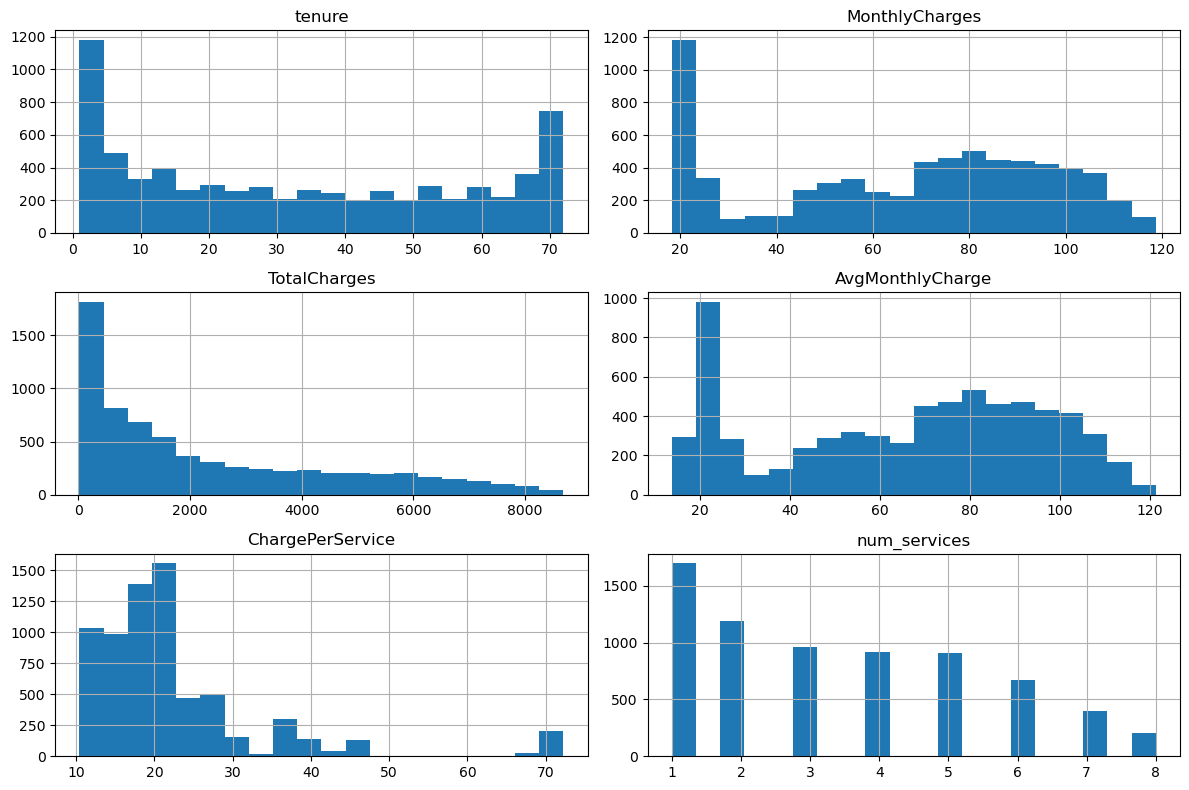

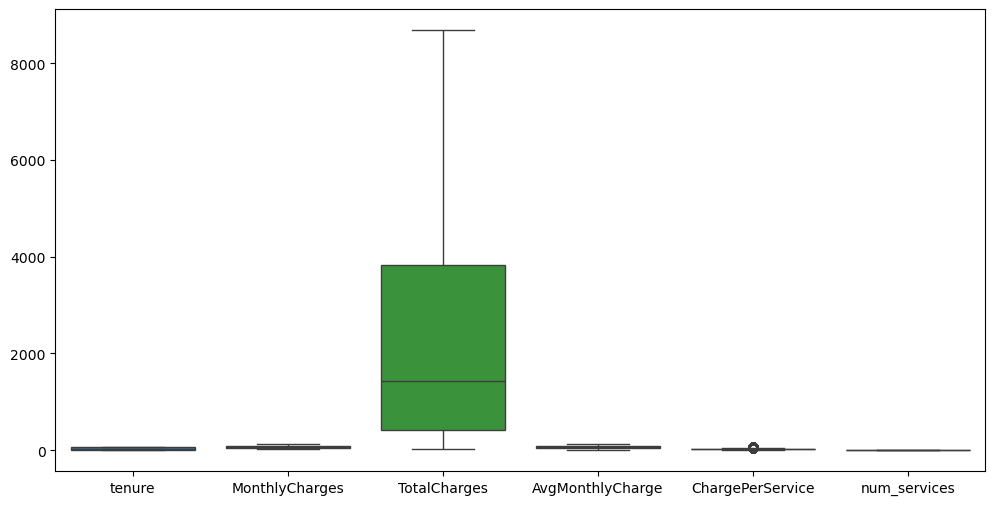

In [247]:
# 수치형 데이터는 스케일링 하기 : StandardScaler 또는 MinMaxScaler 적용 택1 :
# 전체 데이터 분포 확인하기 시각화
# 수치형 변수 목록
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
derived_cols = ['AvgMonthlyCharge', 'ChargePerService', 'num_services']

num_vars = num_cols + derived_cols

# 히스토그램으로 분포 확인
df_model[num_vars].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

# 박스플롯으로 이상치 확인
# 잘안보이면 지우면서 확인하기
plt.figure(figsize=(12,6))
sns.boxplot(data=df_model[num_vars])
plt.show()
# 'ChargePerService'에 이상치 스러운게 존재 ^ 이상치 처리 스킵

# MinMaxScaler 선정 :
# 다른 대부분의 열들이 1과 0으로 구분, 원래 수치형데이터인 'tenure', 'MonthlyCharges', 'TotalCharges' 를 스케일링 하기로 결정
mm = MinMaxScaler()
df_model[num_vars] = mm.fit_transform(df_model[num_vars])

Churn
0    5118
1    1834
Name: count, dtype: int64
Churn
0    0.736191
1    0.263809
Name: proportion, dtype: float64


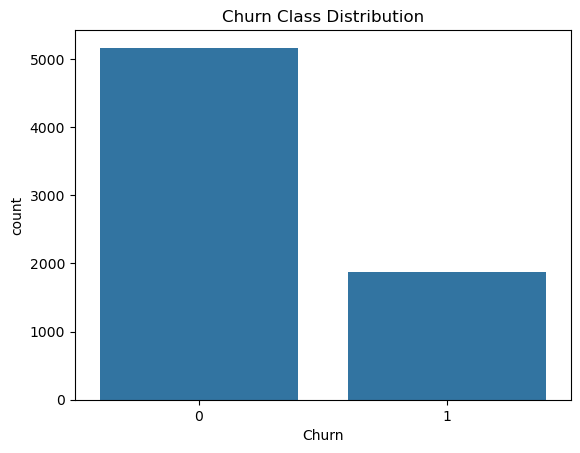

In [248]:
# 고객이탈 여부를 기준으로 데이터 불균형 여부 확인하기
# Churn 값 분포 확인
print(df_model['Churn'].value_counts())

# 비율 확인
print(df_model['Churn'].value_counts(normalize=True))

sns.countplot(x='Churn', data=df)
plt.title('Churn Class Distribution')
plt.show()

# 불균형 비율 약 3:1
# 이탈자수가 더 적은 데이터, 불균형을 이루고 있다는 것을 확인

In [249]:
# 베이스 모델 생성

# 불균형을 어떻게 맞추면 좋을지 고민하기 : 로지스틱 회귀에서 클래스 가중치를 부여하기 class_weight='balanced'
    # 어떻게 가중치가 부여됬는지 조회해보기.
# 소수 클래스 비율이 20~30% 정도이므로, SMOTE 같은 오버샘플링은 꼭 필요하지 않음
# RandomForest를 사용할 경우에도 class_weight='balanced' 옵션으로 충분

# LogisticRegression 모델 생성
model = LogisticRegression(class_weight='balanced', random_state=42)

# 데이터 분할하기
# 타깃 변수
y = df_model['Churn']
# 입력 변수 (타깃 제외)
X = df_model.drop('Churn', axis=1)

# 훈련 데이터 , 시험 데이터 분할하기
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

# 모델 학습
model.fit(x_train,y_train)

# 모델 성능 리포트
y_pred = model.predict(x_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1020
           1       0.50      0.76      0.61       371

    accuracy                           0.74      1391
   macro avg       0.70      0.74      0.70      1391
weighted avg       0.79      0.74      0.75      1391



In [ ]:
# 과적합 여부 판단
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))
# model.score는 기본적으로 accuracy 기준이라 클래스 불균형이 있으면 F1-score나 precision/recall 기반 확인이 더 정확하다.

# F1-score 사용
# 예측
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# F1-score 계산 (binary classification, 소수 클래스 1 기준)
f1_train = f1_score(y_train, y_train_pred, pos_label=1)
f1_test = f1_score(y_test, y_test_pred, pos_label=1)

print("F1-score (Train):", f1_train)
print("F1-score (Test) :", f1_test)

# 차이 계산
diff = f1_train - f1_test
print("Train-Test F1-score 차이:", diff)

# 차잇값이 그리 크지않다 0.019570986555284997
# 과적합 가능성은 낮아 보인다.

0.758496673260205
0.7368799424874192
F1-score (Train): 0.6251744348311471
F1-score (Test) : 0.6056034482758621
Train-Test F1-score 차이: 0.019570986555284997
